# Airbnb Listings — Pricing & Guest Experience Analysis

**Dataset:** [Inside Airbnb](http://insideairbnb.com/get-the-data/)  
**City:** Amsterdam *(update `DATA_DIR` for a different city)*

## Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
import ast

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
DATA_DIR = 'data'

## 0. Data Loading

In [2]:
listings_raw = pd.read_csv(f'{DATA_DIR}/listings.csv.gz', compression='gzip', low_memory=False)
reviews_raw = pd.read_csv(f'{DATA_DIR}/reviews.csv.gz', compression='gzip')

print(f'Listings: {listings_raw.shape[0]} rows, {listings_raw.shape[1]} columns')
print(f'Reviews:  {reviews_raw.shape[0]} rows, {reviews_raw.shape[1]} columns')

Listings: 18177 rows, 85 columns
Reviews:  991795 rows, 6 columns


In [23]:
print("All columns:")
print(listings_raw.columns.tolist())

    # Check if calendar.csv.gz exists and has prices
import os
if os.path.exists(f'{DATA_DIR}/calendar.csv.gz'):
    calendar = pd.read_csv(f'{DATA_DIR}/calendar.csv.gz', compression='gzip')
    print(f'\nCalendar shape: {calendar.shape}')
    print(calendar.head(10))
    print(f'\nCalendar columns: {calendar.columns.tolist()}')

All columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_ni

In [3]:
listings_raw.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,18674,https://www.airbnb.com/rooms/18674,20251214012024,2025-12-14,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,NaN,https://a0.muscache.com/pictures/13031453/413c...,71615,...,4.62,4.81,4.34,Spain - National registration number<br />ESFC...,t,24,24,0,0,0.35
1,2031134,https://www.airbnb.com/rooms/2031134,20251214012024,2025-12-14,city scrape,Sagrada Familia-auditorium. FREE WI-FI.,"Cheap apartment, 45 m2 with a license from the...",NaN,https://a0.muscache.com/pictures/30632356/cf2b...,9100900,...,4.94,4.79,4.71,Barcelona - Regional registration number<br />...,t,1,1,0,0,3.16
2,4415694,https://www.airbnb.com/rooms/4415694,20251214012024,2025-12-14,city scrape,DEEP PURPLE - RAMBLES,Cozy apartment with 2 bedrooms and spacious ba...,NaN,https://a0.muscache.com/pictures/b372938c-e5b2...,12385333,...,4.59,4.67,4.20,Barcelona - Regional registration number<br />...,f,2,2,0,0,1.39


In [4]:
listings_raw.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18177 entries, 0 to 18176
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            18177 non-null  int64  
 1   listing_url                                   18177 non-null  object 
 2   scrape_id                                     18177 non-null  int64  
 3   last_scraped                                  18177 non-null  object 
 4   source                                        18177 non-null  object 
 5   name                                          18177 non-null  object 
 6   description                                   17550 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   18177 non-null  object 
 9   host_id                                       18177 non-null 

---
## 1. Data Cleaning & Preprocessing — Tabular
##### `Person A`
---

In [21]:
listings = listings_raw.copy()

### 1.1 Price

In [22]:
# Only strip currency formatting if the column is stored as string
if listings['price'].dtype == 'object':
    listings['price'] = listings['price'].str.replace('[$,]', '', regex=True).astype(float)
else:
    listings['price'] = pd.to_numeric(listings['price'], errors='coerce')

print(f'Rows before filtering: {len(listings)}')

    # Remove inactive (zero-price) and extreme outliers
listings = listings[listings['price'] > 0]
price_cap = listings['price'].quantile(0.99)
listings = listings[listings['price'] <= price_cap]

print(f'Rows after filtering:  {len(listings)}')
print(f'Price range: ${listings["price"].min():.0f} – ${listings["price"].max():.0f}')
print(f'Median: ${listings["price"].median():.0f} | Mean: ${listings["price"].mean():.0f}')

Rows before filtering: 18177
Rows after filtering:  0
Price range: $nan – $nan
Median: $nan | Mean: $nan


### 1.2 Host Response & Acceptance Rates

In [7]:
for col in ['host_response_rate', 'host_acceptance_rate']:
    if listings[col].dtype == 'object':
        listings[col] = (
            listings[col]
            .str.replace('%', '', regex=False)
            .astype(float) / 100
        )

listings[['host_response_rate', 'host_acceptance_rate']].describe()

,host_response_rate,host_acceptance_rate
count,0.0,0.0
mean,NaN,NaN
std,NaN,NaN
min,NaN,NaN
25%,NaN,NaN
50%,NaN,NaN
75%,NaN,NaN
max,NaN,NaN


### 1.3 Bathrooms

In [8]:
listings['bathrooms'] = (
    listings['bathrooms_text']
    .str.extract(r'(\d+\.?\d*)')
    .astype(float)
)
listings.loc[
    listings['bathrooms_text'].str.contains('Half|half', na=False),
    'bathrooms'
] = 0.5

listings['bathrooms'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: bathrooms, dtype: float64

### 1.4 Amenities

In [9]:
def parse_amenities(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except (ValueError, SyntaxError):
        return []

listings['amenities_list'] = listings['amenities'].apply(parse_amenities)
listings['amenities_count'] = listings['amenities_list'].apply(len)

KEY_AMENITIES = [
    'Wifi', 'Air conditioning', 'Kitchen', 'Washer', 'Dryer',
    'Free parking', 'Pool', 'Hot tub', 'TV', 'Elevator',
    'Gym', 'Self check-in', 'Smoke alarm'
]

for amenity in KEY_AMENITIES:
    col_name = 'has_' + amenity.lower().replace(' ', '_')
    listings[col_name] = listings['amenities_list'].apply(
        lambda x, a=amenity: int(any(a.lower() in item.lower() for item in x))
    )

print(f'Median amenities per listing: {listings["amenities_count"].median():.0f}')
print('\nKey amenity prevalence:')
amenity_cols = [c for c in listings.columns if c.startswith('has_')]
print(listings[amenity_cols].mean().sort_values(ascending=False).to_string())

Median amenities per listing: nan

Key amenity prevalence:
has_availability        NaN
has_wifi                NaN
has_air_conditioning    NaN
has_kitchen             NaN
has_washer              NaN
has_dryer               NaN
has_free_parking        NaN
has_pool                NaN
has_hot_tub             NaN
has_tv                  NaN
has_elevator            NaN
has_gym                 NaN
has_self_check-in       NaN
has_smoke_alarm         NaN


### 1.5 Host Tenure

In [10]:
listings['host_since'] = pd.to_datetime(listings['host_since'], errors='coerce')
listings['host_tenure_years'] = (
    (pd.Timestamp.now() - listings['host_since']).dt.days / 365.25
)

listings['host_tenure_years'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: host_tenure_years, dtype: float64

### 1.6 Boolean Encoding

In [11]:
bool_map = {'t': 1, 'f': 0}
bool_cols = ['host_is_superhost', 'host_has_profile_pic',
             'host_identity_verified', 'instant_bookable']

for col in bool_cols:
    listings[col] = listings[col].map(bool_map).fillna(0).astype(int)

# Encode room_type for modelling
listings['room_type_encoded'] = LabelEncoder().fit_transform(listings['room_type'])

### 1.7 Missing Value Imputation

In [12]:
num_impute = [
    'bedrooms', 'beds', 'bathrooms',
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'host_response_rate',
    'host_acceptance_rate', 'reviews_per_month', 'host_tenure_years'
]

for col in num_impute:
    if col in listings.columns:
        n_missing = listings[col].isna().sum()
        if n_missing > 0:
            median_val = listings[col].median()
            print(f'{col}: {n_missing} missing -> median={median_val:.2f}')
            listings[col] = listings[col].fillna(median_val)

### 1.8 Drop Irrelevant Columns

In [13]:
drop_cols = [
    'listing_url', 'scrape_id', 'last_scraped', 'source', 'picture_url',
    'host_url', 'host_thumbnail_url', 'host_picture_url', 'host_location',
    'host_about', 'host_neighbourhood', 'host_verifications',
    'calendar_updated', 'calendar_last_scraped', 'license',
    'neighbourhood', 'description', 'neighborhood_overview', 'name',
    'bathrooms_text', 'amenities', 'amenities_list',
    'minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_maximum_nights', 'maximum_maximum_nights',
    'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
    'host_name', 'first_review', 'last_review', 'host_since',
    'host_id', 'host_total_listings_count',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms'
]

listings.drop(columns=[c for c in drop_cols if c in listings.columns], inplace=True)

print(f'Final shape: {listings.shape}')
listings.dtypes

Final shape: (0, 65)


id                             int64
host_profile_id                int64
host_profile_url              object
hosts_time_as_user_years     float64
hosts_time_as_user_months    float64
                              ...   
has_gym                       object
has_self_check-in             object
has_smoke_alarm               object
host_tenure_years            float64
room_type_encoded            float64
Length: 65, dtype: object

### 1.9 Save Clean Dataset

In [14]:
listings.to_csv(f'{DATA_DIR}/listings_clean.csv', index=False)
print(f'Saved {len(listings)} rows to {DATA_DIR}/listings_clean.csv')

Saved 0 rows to data/listings_clean.csv


---
### ═══ END Person A: Data Cleaning & Preprocessing (Tabular) ═══
### ▶ START Person B: Data Cleaning & Preprocessing (Text/Reviews)
---

*Person B — place your text cleaning cells here.*

---
### ═══ END Person B: Data Cleaning & Preprocessing (Text/Reviews) ═══
### ▶ MERGE POINT: Add sentiment column to listings DataFrame
---

In [15]:
# Merge Person B's sentiment scores into the listings DataFrame.
# Expected input: CSV with columns ['listing_id', 'avg_sentiment']
#
# sentiment = pd.read_csv(f'{DATA_DIR}/review_sentiments.csv')
# listings = listings.merge(sentiment, left_on='id', right_on='listing_id', how='left')
# listings['avg_sentiment'] = listings['avg_sentiment'].fillna(0)

---
## 2. EDA / Data Visualization
##### `Person A`
---

In [16]:
# Uncomment if starting from a fresh session
# listings = pd.read_csv(f'{DATA_DIR}/listings_clean.csv')

### 2.1 Price Distribution

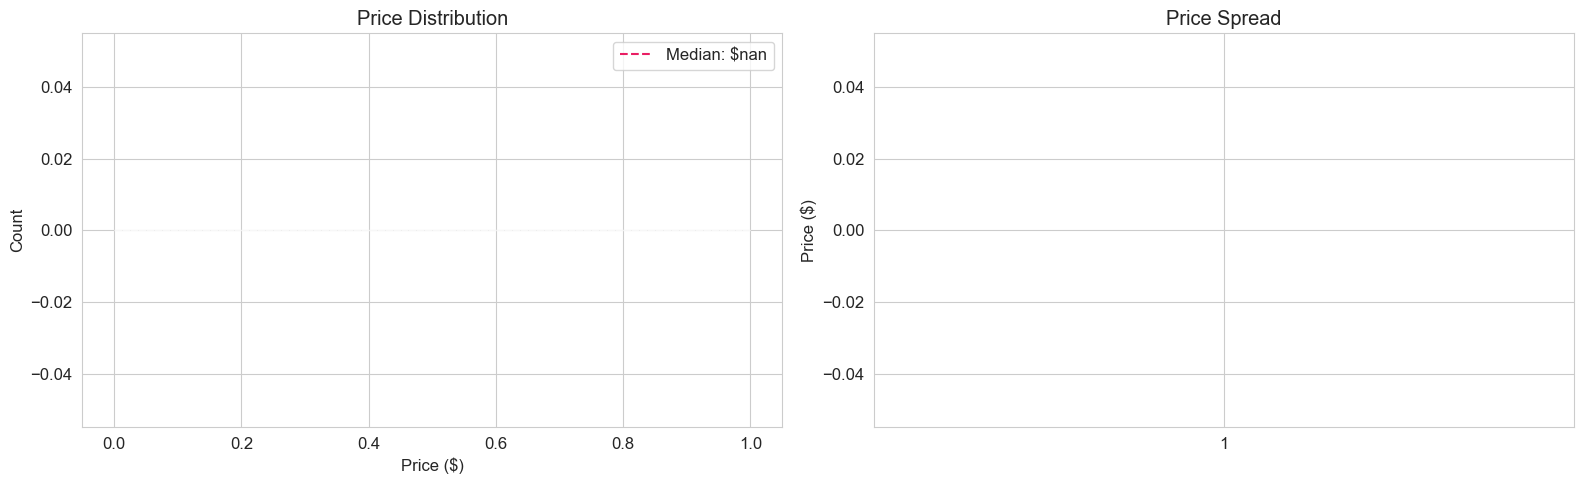

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: price, dtype: float64


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(listings['price'], bins=80, color='#2196F3',
             edgecolor='white', alpha=0.85)
axes[0].axvline(listings['price'].median(), color='#E91E63',
               linestyle='--', label=f'Median: ${listings["price"].median():.0f}')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Distribution')
axes[0].legend()

axes[1].boxplot(listings['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.6))
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Price Spread')

plt.tight_layout()
plt.show()

print(listings['price'].describe())

### 2.2 Room Type Breakdown

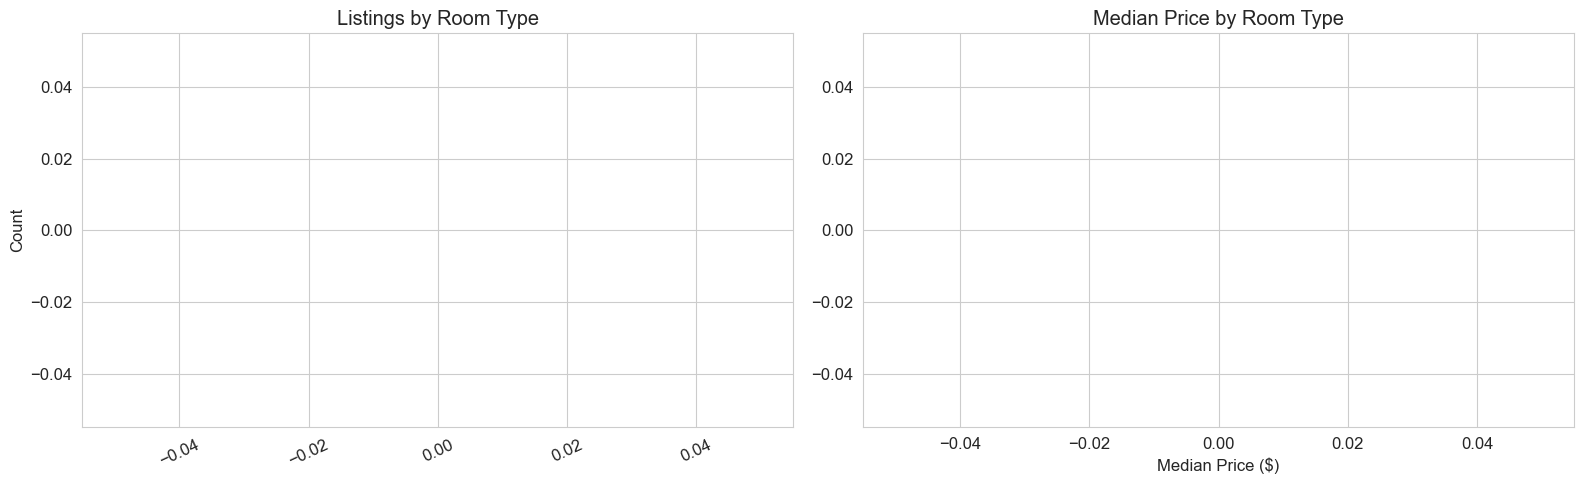

In [18]:
room_counts = listings['room_type'].value_counts()
room_prices = listings.groupby('room_type')['price'].median().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(room_counts.index, room_counts.values, color='#26A69A', edgecolor='white')
axes[0].set_title('Listings by Room Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)

axes[1].barh(room_prices.index, room_prices.values, color='#FF7043', edgecolor='white')
axes[1].set_title('Median Price by Room Type')
axes[1].set_xlabel('Median Price ($)')

plt.tight_layout()
plt.show()

### 2.3 Neighborhood Analysis

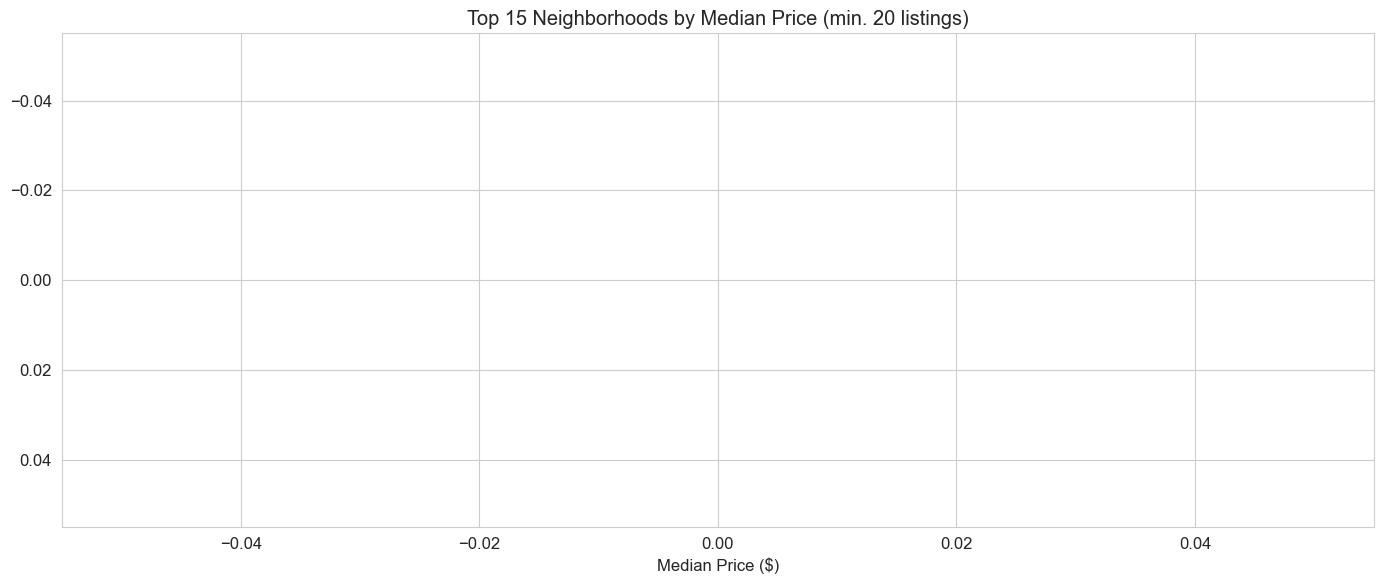

In [19]:
neighbourhood_col = 'neighbourhood_cleansed'
top_n = 15

neigh_stats = (
    listings.groupby(neighbourhood_col)['price']
    .agg(['median', 'count', 'mean'])
    .sort_values('median', ascending=False)
)
neigh_stats = neigh_stats[neigh_stats['count'] >= 20].head(top_n)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(neigh_stats.index, neigh_stats['median'],
               color='#7E57C2', edgecolor='white')
ax.set_xlabel('Median Price ($)')
ax.set_title(f'Top {top_n} Neighborhoods by Median Price (min. 20 listings)')
ax.invert_yaxis()

for bar, count in zip(bars, neigh_stats['count']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'n={count}', va='center', fontsize=9, color='#555')

plt.tight_layout()
plt.show()

### 2.4 Superhost Analysis

In [20]:
superhost_stats = listings.groupby('host_is_superhost').agg(
    count=('price', 'size'),
    median_price=('price', 'median'),
    mean_rating=('review_scores_rating', 'mean'),
    mean_reviews=('number_of_reviews', 'mean')
)
superhost_stats.index = ['Regular Host', 'Superhost']
print(superhost_stats.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

listings.boxplot(column='price', by='host_is_superhost', ax=axes[0],
                 patch_artist=True, boxprops=dict(facecolor='#42A5F5', alpha=0.6))
axes[0].set_xticklabels(['Regular', 'Superhost'])
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('')

listings.boxplot(column='review_scores_rating', by='host_is_superhost', ax=axes[1],
                 patch_artist=True, boxprops=dict(facecolor='#66BB6A', alpha=0.6))
axes[1].set_xticklabels(['Regular', 'Superhost'])
axes[1].set_title('Review Score Rating')
axes[1].set_xlabel('')

listings.boxplot(column='number_of_reviews', by='host_is_superhost', ax=axes[2],
                 patch_artist=True, boxprops=dict(facecolor='#FFA726', alpha=0.6))
axes[2].set_xticklabels(['Regular', 'Superhost'])
axes[2].set_title('Number of Reviews')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

ValueError: Length mismatch: Expected axis has 0 elements, new values have 2 elements

### 2.5 Capacity vs. Price

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

acc_price = listings.groupby('accommodates')['price'].median()
acc_price = acc_price[acc_price.index <= 10]
acc_price.plot.bar(ax=axes[0], color='#26C6DA', edgecolor='white')
axes[0].set_title('Median Price by Guest Capacity')
axes[0].set_xlabel('Accommodates')
axes[0].set_ylabel('Median Price ($)')

bed_price = listings.groupby('bedrooms')['price'].median()
bed_price = bed_price[bed_price.index <= 6]
bed_price.plot.bar(ax=axes[1], color='#AB47BC', edgecolor='white')
axes[1].set_title('Median Price by Bedrooms')
axes[1].set_xlabel('Bedrooms')
axes[1].set_ylabel('Median Price ($)')

plt.tight_layout()
plt.show()

### 2.6 Correlation Heatmap

In [ ]:
corr_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
    'host_is_superhost', 'amenities_count', 'host_tenure_years',
    'availability_365', 'minimum_nights', 'instant_bookable'
]
corr_cols = [c for c in corr_cols if c in listings.columns]

corr = listings[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)
print('Strongest correlations with price:')
print(price_corr.head(8).to_string())

### 2.7 Geographic Distribution

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    listings['longitude'], listings['latitude'],
    c=listings['price'], cmap='YlOrRd',
    alpha=0.4, s=5,
    vmin=listings['price'].quantile(0.05),
    vmax=listings['price'].quantile(0.95)
)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('Price ($)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Listings by Location (colored by price)')

plt.tight_layout()
plt.show()

### 2.8 Review Score Distributions

In [ ]:
score_cols = [
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value'
]
score_cols = [c for c in score_cols if c in listings.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(score_cols):
    axes[i].hist(listings[col].dropna(), bins=20,
                color='#5C6BC0', edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('review_scores_', '').title())
    axes[i].axvline(listings[col].median(), color='#E91E63',
                   linestyle='--', alpha=0.7)

for j in range(len(score_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Review Score Distributions (dashed line = median)', y=1.01)
plt.tight_layout()
plt.show()

---
### ═══ END Person A: EDA / Data Visualization ═══
### ▶ START Person B: Sentiment Analysis
---

*Person B — place your sentiment analysis cells here.*

---
### ═══ END Person B: Sentiment Analysis ═══
### ▶ START Person B: Feature Importance / PCA
---

*Person B — place your PCA / feature importance cells here.*

---
### ═══ END Person B: Feature Importance / PCA ═══
---

---
## 5. Supervised Model — Price Prediction
##### `Person A`
---

### 5.1 Feature Preparation

In [ ]:
feature_cols = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'maximum_nights',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm',
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'reviews_per_month',
    'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
    'host_response_rate', 'host_acceptance_rate',
    'host_listings_count', 'host_tenure_years',
    'instant_bookable', 'amenities_count', 'room_type_encoded',
    'calculated_host_listings_count', 'latitude', 'longitude'
]

amenity_flags = [c for c in listings.columns if c.startswith('has_')]
feature_cols += amenity_flags

# Include sentiment if available from Person B
if 'avg_sentiment' in listings.columns:
    feature_cols.append('avg_sentiment')

feature_cols = [c for c in feature_cols if c in listings.columns]

X = listings[feature_cols].copy().fillna(0)
y = listings['price'].copy()

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]}')

### 5.2 Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

### 5.3 Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200, max_depth=20, min_samples_split=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest')
print(f'  R2:   {r2_score(y_test, y_pred_rf):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred_rf):.2f}')

### 5.4 Gradient Boosting Regressor

In [ ]:
gb = GradientBoostingRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print('Gradient Boosting')
print(f'  R2:   {r2_score(y_test, y_pred_gb):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.2f}')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred_gb):.2f}')

### 5.5 Hyperparameter Tuning (Best Model)

In [ ]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9],
    'min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid,
    n_iter=20, cv=3, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
search.fit(X_train, y_train)

best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f'Best params: {search.best_params_}')
print(f'\nTuned Gradient Boosting')
print(f'  R2:   {r2_score(y_test, y_pred_best):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred_best):.2f}')

### 5.6 Model Comparison

In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Tuned GB'],
    'R2': [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_best)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        np.sqrt(mean_squared_error(y_test, y_pred_best))
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb),
        mean_absolute_error(y_test, y_pred_best)
    ]
}).round(4)

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results))
w = 0.25
ax.bar(x - w, results['R2'], w, label='R2', color='#42A5F5')
ax.bar(x, results['RMSE'] / results['RMSE'].max(), w,
       label='RMSE (normalized)', color='#EF5350')
ax.bar(x + w, results['MAE'] / results['MAE'].max(), w,
       label='MAE (normalized)', color='#66BB6A')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.legend()
ax.set_title('Model Comparison')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

### 5.7 Feature Importance

In [ ]:
importance = pd.Series(
    best_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
importance.head(20).plot.barh(ax=ax, color='#7E57C2', edgecolor='white')
ax.set_title('Top 20 Feature Importances (Tuned Gradient Boosting)')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importance.head(10).to_string())

### 5.8 Error Analysis

In [ ]:
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=8, color='#42A5F5')
lims = [min(y_test.min(), y_pred_best.min()),
        max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, '--', color='#E91E63', linewidth=1.5)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Predicted vs. Actual')

# Residual distribution
axes[1].hist(residuals, bins=60, color='#26A69A',
             edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='#E91E63', linestyle='--')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

# Residuals vs predicted
axes[2].scatter(y_pred_best, residuals, alpha=0.3, s=8, color='#FF7043')
axes[2].axhline(0, color='#E91E63', linestyle='--')
axes[2].set_xlabel('Predicted Price ($)')
axes[2].set_ylabel('Residual ($)')
axes[2].set_title('Residuals vs. Predicted')

plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals.mean():.2f}')
print(f'Residual std:  {residuals.std():.2f}')

### 5.9 Cross-Validation

In [ ]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'5-Fold CV R2 scores: {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

---
### ═══ END Person A: Supervised Model — Price Prediction ═══
### ▶ START Person B: Unsupervised Model — Market Segmentation
---

*Person B — place your clustering / market segmentation cells here.*

---
### ═══ END Person B: Unsupervised Model — Market Segmentation ═══
---

---
## 6. Conclusions & Key Insights
##### `Both`
---

*Complete after all sections are integrated.*

**Guiding questions:**
1. What are the strongest predictors of listing price?
2. Does the superhost badge justify a price premium?
3. Which amenities drive price vs. satisfaction?
4. Where do text sentiment and numeric ratings diverge?
5. Do data-driven clusters align with market intuition?
6. What are the practical implications for hosts?